In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageFilter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [ ]:
DATASET_PATH = "C:/Users/AHMAD ADAM HAKIMI/Downloads/Machine_Learning_Project/PlantVillage"
OUTPUT_PATH = "C:/Users/AHMAD ADAM HAKIMI/Downloads/Machine_Learning_Project/PlantVillage_Balanced"

IMG_SIZE = 640
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
AUGMENT_TIMES = 3
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("✅ Config Ready.")

✅ Config Ready.


In [5]:
class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print(f"Found {len(class_names)} classes found:")
for i, c in enumerate(class_names):
    imgs = os.listdir(os.path.join(DATASET_PATH, c))
    print(f"  [{i + 1}] {c}  →  {len(imgs)} images")

Found 10 classes found:
  [1] Tomato_Bacterial_spot  →  2127 images
  [2] Tomato_Early_blight  →  1000 images
  [3] Tomato_Late_blight  →  1909 images
  [4] Tomato_Leaf_Mold  →  952 images
  [5] Tomato_Septoria_leaf_spot  →  1771 images
  [6] Tomato_Spider_mites_Two_spotted_spider_mite  →  1676 images
  [7] Tomato__Target_Spot  →  1404 images
  [8] Tomato__Tomato_YellowLeaf__Curl_Virus  →  3209 images
  [9] Tomato__Tomato_mosaic_virus  →  373 images
  [10] Tomato_healthy  →  1591 images


In [ ]:
import shutil

# Check the folder whether it is exists or not
if os.path.exists(OUTPUT_PATH):
    print("⚠️ Folder exist! Deleting...")
    shutil.rmtree(OUTPUT_PATH)
    print("✅ Old folder deleted.")

# create new folder for splitting the dataset
for split in ['train', 'val', 'test']:
    for cls in class_names:
        Path(f"{OUTPUT_PATH}/{split}/{cls}").mkdir(parents=True, exist_ok=True)

print(f"✅ Fresh folders created at: {OUTPUT_PATH}/")
print("   train/  val/  test/  — each with 10 class subfolders")

⚠️ Folder exist! Deleting...
✅ Old folder deleted.
✅ Fresh folders created at: C:/Users/AHMAD ADAM HAKIMI/Downloads/Machine_Learning_Project/PlantVillage_Balanced/
   train/  val/  test/  — each with 10 class subfolders


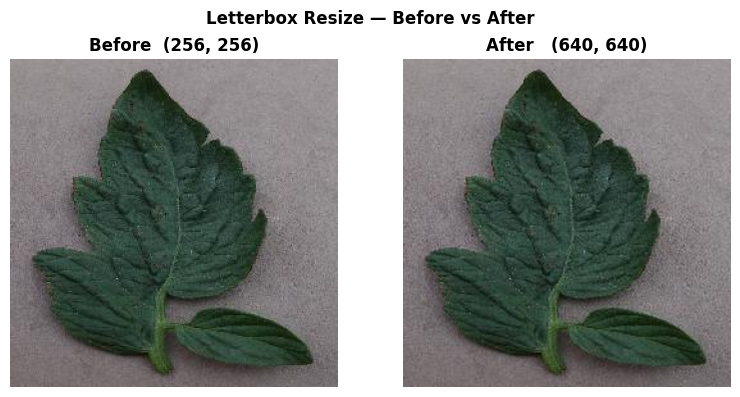

✅ Preprocessing function ready


In [ ]:
def preprocess_image(img_path, size=640):

    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    ratio   = size / max(w, h)
    new_w   = int(w * ratio)
    new_h   = int(h * ratio)
    resized = img.resize((new_w, new_h), Image.LANCZOS)
    padded  = Image.new('RGB', (size, size), (114, 114, 114))
    padded.paste(resized, ((size - new_w)//2, (size - new_h)//2))
    return padded
 
sample_cls  = class_names[0]
sample_file = os.listdir(os.path.join(DATASET_PATH, sample_cls))[0]
raw  = Image.open(os.path.join(DATASET_PATH, sample_cls, sample_file)).convert('RGB')
proc = preprocess_image(os.path.join(DATASET_PATH, sample_cls, sample_file))
 
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(raw);  ax[0].set_title(f'Before  {raw.size}',  fontweight='bold'); ax[0].axis('off')
ax[1].imshow(proc); ax[1].set_title(f'After   {proc.size}', fontweight='bold'); ax[1].axis('off')
plt.suptitle('Letterbox Resize — Before vs After', fontweight='bold')
plt.tight_layout()
plt.savefig('preprocess/preprocess_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Preprocessing function ready")

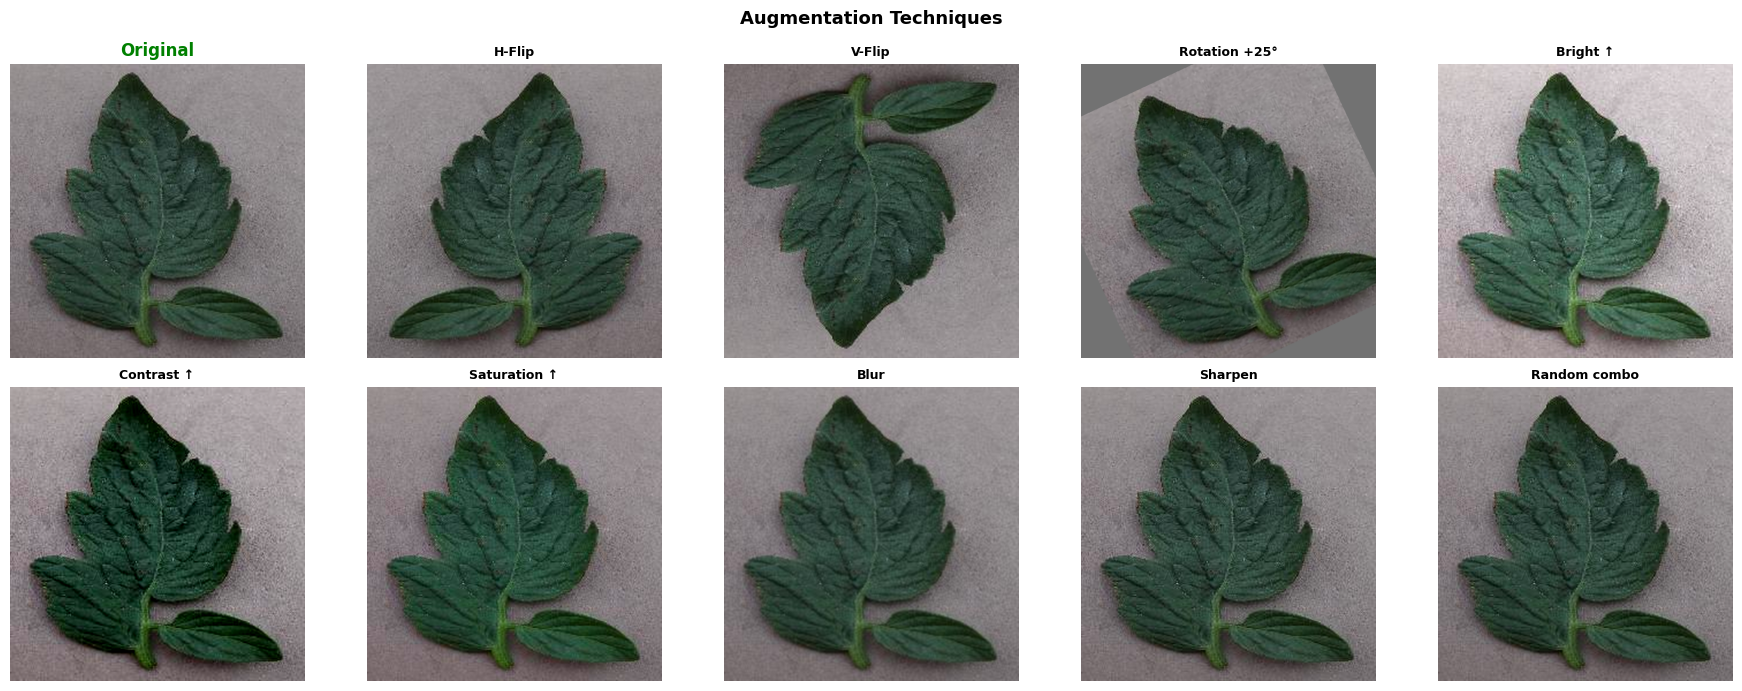

✅ Augmentation function ready


In [ ]:
def augment_image(img):
    """8 random augmentations with random parameters, applied with certain probabilities."""
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)          # H-Flip
    if random.random() > 0.7:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)          # V-Flip
    if random.random() > 0.4:
        img = img.rotate(random.uniform(-30, 30),
                         fillcolor=(114,114,114))            # Rotation
    if random.random() > 0.4:
        img = ImageEnhance.Brightness(img).enhance(
                         random.uniform(0.7, 1.3))           # Brightness
    if random.random() > 0.4:
        img = ImageEnhance.Contrast(img).enhance(
                         random.uniform(0.7, 1.3))           # Contrast
    if random.random() > 0.5:
        img = ImageEnhance.Color(img).enhance(
                         random.uniform(0.7, 1.4))           # Saturation
    if random.random() > 0.8:
        img = img.filter(ImageFilter.GaussianBlur(
                         radius=random.uniform(0.5, 1.5)))   # Blur
    if random.random() > 0.7:
        img = ImageEnhance.Sharpness(img).enhance(
                         random.uniform(1.2, 2.0))           # Sharpen
    return img
 
# Visualize all the augmentation process from H-FLip until Sharpen
orig = preprocess_image(os.path.join(DATASET_PATH, sample_cls, sample_file))
 
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
axes[0].imshow(orig); axes[0].set_title('Original', fontweight='bold', color='green')
axes[0].axis('off')
 
labels = ["H-Flip","V-Flip","Rotation +25°","Bright ↑","Contrast ↑",
          "Saturation ↑","Blur","Sharpen","Random combo"]
transforms = [
    lambda i: i.transpose(Image.FLIP_LEFT_RIGHT),
    lambda i: i.transpose(Image.FLIP_TOP_BOTTOM),
    lambda i: i.rotate(25, fillcolor=(114,114,114)),
    lambda i: ImageEnhance.Brightness(i).enhance(1.4),
    lambda i: ImageEnhance.Contrast(i).enhance(1.4),
    lambda i: ImageEnhance.Color(i).enhance(1.5),
    lambda i: i.filter(ImageFilter.GaussianBlur(radius=1.2)),
    lambda i: ImageEnhance.Sharpness(i).enhance(2.0),
    lambda i: augment_image(i.copy()),
]
for idx, (lbl, fn) in enumerate(zip(labels, transforms)):
    axes[idx+1].imshow(fn(orig.copy()))
    axes[idx+1].set_title(lbl, fontsize=9, fontweight='bold')
    axes[idx+1].axis('off')
 
plt.suptitle('Augmentation Techniques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocess/preprocess_augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Augmentation function ready")

In [13]:
print("📂 Splitting dataset...")
split_counts = {'train':0, 'val':0, 'test':0}
 
for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(all_imgs)
 
    n       = len(all_imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
 
    splits = {
        'train': all_imgs[:n_train],
        'val':   all_imgs[n_train:n_train+n_val],
        'test':  all_imgs[n_train+n_val:]
    }
 
    for split, files in splits.items():
        for f in files:
            src  = os.path.join(cls_path, f)
            proc = preprocess_image(src, IMG_SIZE)
            dst  = os.path.join(OUTPUT_PATH, split, cls, f)
            proc.save(dst, quality=95)
        split_counts[split] += len(files)
 
    print(f"  {cls:<48} train:{len(splits['train'])}  val:{len(splits['val'])}  test:{len(splits['test'])}")
 
print(f"\n✅ Split done — Train:{split_counts['train']}  Val:{split_counts['val']}  Test:{split_counts['test']}")

📂 Splitting dataset...
  Tomato_Bacterial_spot                            train:1488  val:319  test:320
  Tomato_Early_blight                              train:700  val:150  test:150
  Tomato_Late_blight                               train:1336  val:286  test:287
  Tomato_Leaf_Mold                                 train:666  val:142  test:144
  Tomato_Septoria_leaf_spot                        train:1239  val:265  test:267
  Tomato_Spider_mites_Two_spotted_spider_mite      train:1173  val:251  test:252
  Tomato__Target_Spot                              train:982  val:210  test:212
  Tomato__Tomato_YellowLeaf__Curl_Virus            train:2245  val:481  test:482
  Tomato__Tomato_mosaic_virus                      train:261  val:55  test:57
  Tomato_healthy                                   train:1113  val:238  test:240

✅ Split done — Train:11203  Val:2397  Test:2411


In [14]:
print(f"🔁 Augmenting train set ({AUGMENT_TIMES}x each)...")
aug_total = 0
 
for cls in class_names:
    train_path = os.path.join(OUTPUT_PATH, 'train', cls)
    train_imgs = [f for f in os.listdir(train_path)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
 
    for img_file in train_imgs:
        img  = Image.open(os.path.join(train_path, img_file)).convert('RGB')
        stem = Path(img_file).stem
        for i in range(AUGMENT_TIMES):
            aug = augment_image(img.copy())
            aug.save(os.path.join(train_path, f"{stem}_aug{i+1}.jpg"), quality=95)
            aug_total += 1
 
print(f"✅ {aug_total} augmented images added to train set")

🔁 Augmenting train set (3x each)...
✅ 33609 augmented images added to train set


In [15]:
print("\n" + "="*55)
print("  FINAL DATASET SUMMARY")
print("="*55)
for split in ['train','val','test']:
    total = sum(
        len(os.listdir(os.path.join(OUTPUT_PATH, split, c)))
        for c in class_names
    )
    print(f"  {split.upper():<8}: {total:>6} images")
 
print(f"\n  Image size  : {IMG_SIZE}x{IMG_SIZE}px")
print(f"  Augment     : {AUGMENT_TIMES}x (train only)")
print(f"  Resize      : Letterbox — no distortion")

yaml_lines = [
    f"path: {os.path.abspath(OUTPUT_PATH)}",
    "train: train",
    "val: val",
    "test: test",
    "",
    f"nc: {len(class_names)}",
    "names:",
]
for cls in class_names:
    yaml_lines.append(f"  - {cls}")
 
yaml_path = os.path.join(OUTPUT_PATH, "dataset.yaml")
with open(yaml_path, "w") as f:
    f.write("\n".join(yaml_lines))
 
print(f"\n✅ dataset.yaml saved → {yaml_path}")


  FINAL DATASET SUMMARY
  TRAIN   :  44812 images
  VAL     :   2397 images
  TEST    :   2411 images

  Image size  : 640x640px
  Augment     : 3x (train only)
  Resize      : Letterbox — no distortion

✅ dataset.yaml saved → C:/Users/AHMAD ADAM HAKIMI/Downloads/Machine_Learning_Project/PlantVillage_Balanced\dataset.yaml
